<a href="https://colab.research.google.com/github/PedroConst/EQE-358-Metodos-Numericos/blob/main/Lab/Lab_02_Coluna_Extra%C3%A7%C3%A3o_L%C3%ADquido_L%C3%ADquido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 02 – Coluna de Extração Líquido-Líquido**

## Objetivos
- Compreender o princípio de funcionamento de colunas de extração
- Implementar matrizes esparsas, de banda e largas
- Resolver um sistema linear em Python usando Eliminação Gaussiana e/ou Decomposição LU
- Avaliar as vantagens do Método de Decomposição LU

---

## Contexto
Links para vídeos:
- [Colunas de extração líquido-líquido](https://youtube.com/shorts/h8sbmkcz5sY?si=IffwzqnsO0CJg9bb)

- [Koch Modular KARR® Column ](https://youtu.be/TlJaSK6YEp4?si=UWFAtjyIyUkDQm_w)



## **Coluna Escala Piloto**

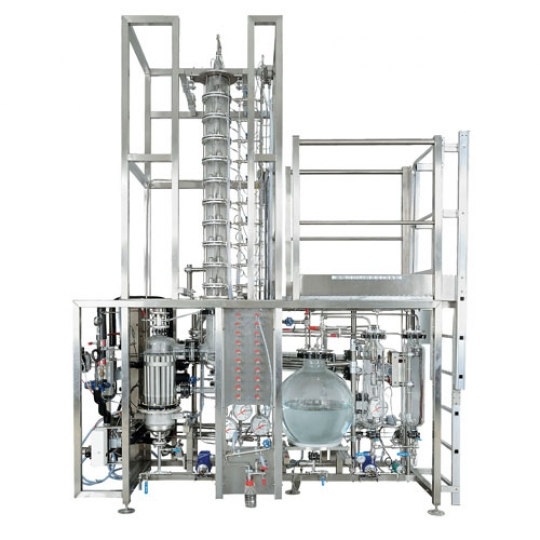

##**Coluna em Escala Industrial**

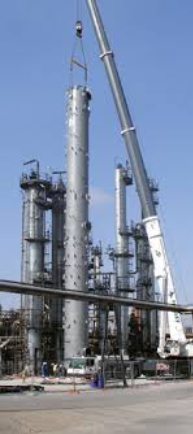

## **Modelo Matemático**

Relação de equilíbrio termodinâmico:

$$
y_i=Kx_i
\tag{1}
$$

Balanços de massa em cada estágio da coluna:

$$
\begin{cases}
x_0F+y_2S=x_1F+y_1S,\ \ \ \ \ \  (i=1)
\\[6pt]
x_{i-1}F+y_{i+1}S=x_iF+y_iS,\ \ (2\le i\le n-1)
\\[6pt]
x_{n-1}F+y_0S=x_nF+y_nS,\ \ \ \ \  (i=n)
\end{cases}
\tag{2}
$$

##**🔹 Passo 1 – Importar bibliotecas**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

##**🔹 Passo 2 – Definir o Método LU**

In [ ]:
# Função que realiza a decomposição A = LU
def linear_LU(A):
    n = A.shape[0]
    U = np.zeros((n, n))
    L = np.eye(n)  # coloca 1 na diagonal

    for k in range(n - 1):
        for i in range(k + 1, n):
            m = A[i, k] / A[k, k]
            A[i, k] = m  # armazena entrada para L
            for j in range(k + 1, n):
                A[i, j] = A[i, j] - m * A[k, j]

    for i in range(n):
        for j in range(i, n):
            U[i, j] = A[i, j]

    for i in range(1, n):
        for j in range(i):
            L[i, j] = A[i, j]

    return L, U

In [ ]:
# Função que resolve o sistema linear LUx=b
def linear_LU_forward_back(L, U, b):
    n = len(b)

    # Realiza a substituição direta (forward substitution)
    y = np.zeros(n)
    y[0] = b[0]
    for i in range(1, n):
        y[i] = b[i]
        for j in range(i):
            y[i] = y[i] - L[i, j] * y[j]

    # Realiza a substituição reversa (back substitution)
    x = np.zeros(n)
    x[n-1] = y[n-1] / U[n-1, n-1]
    for i in range(n-2, -1, -1):
        S = y[i]
        for j in range(i+1, n):
            S = S - U[i, j] * x[j]
        x[i] = S / U[i, i]

    return x

##**🔹 Passo 3 – Inserir Dados do Problema**

In [ ]:
n = ...      # Número de Estágios
S = ...    # Vazão do solvente (kg/h)
F = ...    # Vazão da alimentação (kg/h)
yo = ...    # Concentração inicial de soluto no solvente
K = ...     # Constante de Equilíbrio
xin = ...  # Concentração inicial de soluto na alimentação

##**🔹 Passo 4 – Alocar Variáveis**

In [ ]:
# Inicializar Matrizes e Vetores
A = ...
b = ...
x = ...

##**🔹 Passo 5 – Construir a matriz do sistema**

In [ ]:
# Montar o Sistema de Equações

# Primeiro Estágio
A[0, 0] = ...
A[0, 1] = ...
b[0] = ...

# Estágios Interiores
for i in range(n):
    A[i, i - 1] = ...
    A[i, i] = ...
    A[i, i + 1] = ...

# Último Estágio
A[n-1, n - 2] = ...
A[n-1, n - 1] = ...
b[n-1] = ...

##**🔹 Passo 6 – Resolver o Sistema Linear**

In [ ]:
# Chamar a Função de Decomposição LU
# Eliminação (Forward) para obter L e U
L, U = ...

# Chamar a Função de Substituição (Forward) Ly = b
# Substituição (Backward) Ux = y
x = ...

##**🔹 Passo 7 – Visualizar Resultados**

In [ ]:
# Imprimir Tabela
print('n \t xi \t\t yi')
print('--------------------------------')
print(f'0 \t {xin:.4f} \t ------')
for i in range(n):
    print(f'{i+1} \t {x[i]:.4f} \t {K*x[i]:.4f}')
print('--------------------------------')

In [ ]:
# Plotar o Gráfico
nstage = ...

plt.plot(0, xin, 'ok')  # Concentração inicial
plt.plot(...,...,'.b')  # x no estágio i
plt.plot(...,...,'.r')  # y no estágio i

plt.legend(['...', '...', '...'])

plt.xlabel('...')
plt.ylabel('...')
plt.title('...')

plt.show()

##**🔹 Passo 8 – Definir Várias Concentrações**

In [ ]:
# Concentração inicial de soluto na alimentação
xin = ...

##**🔹 Passo 9 – Alocar Variáveis**

In [ ]:
# Inicializar/Alocar variáveis
A = ...
b = ...

ntimes = len(...)
x = ... # Definir x como uma matriz!

In [ ]:
# Montar o Sistema de Equações

# Primeiro Estágio
A[..., ...] = ...
A[..., ...] = ...

# Estágios Interiores
for i in range(n):
    A[..., ...] = ...
    A[..., ...] = ...
    A[..., ...] = ...

# Último Estágio
A[..., ...] = ...
A[..., ...] = ...
b[...] = ...

In [ ]:
# Resolver por Decomposição LU
# Eliminação (Forward) para obter L e U
L, U = ...

# Fazer um loop para diferentes concetrações iniciais
for k in range(..., ...):
    b[0] = -xin[k]
    x[:,k] = ...

In [ ]:
# Plotar o Gráfico
nstage = np.arange(1,n+1,1)

for k in range(..., ...):
    plt.plot(0, ..., 'ok')  # Concentracao inicial
    plt.plot(..., ..., 'b') # x no estagio i

plt.xlabel('...')
plt.ylabel('...')
plt.title('...')
plt.show()